<a href="https://colab.research.google.com/github/venkata18167/CSA6301---THREAT-INTELLIGENCE-AND-NETWORK-SECURITY/blob/main/23_Log_Analysis_and_Brute_Force_Pattern_Detection_pynb.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

Sample log file created successfully.

Authentication Logs
              Timestamp    IP Address Username   Status
0   2026-08-03 10:00:01  192.168.1.10    admin   FAILED
1   2026-08-03 10:00:15  192.168.1.10    admin   FAILED
2   2026-08-03 10:00:40  192.168.1.10    admin   FAILED
3   2026-08-03 10:01:00  192.168.1.10    admin   FAILED
4   2026-08-03 10:01:20  192.168.1.10    admin   FAILED
5   2026-08-03 10:01:35  192.168.1.10    admin   FAILED
6   2026-08-03 10:02:00  192.168.1.20     john   FAILED
7   2026-08-03 10:02:20  192.168.1.20     john  SUCCESS
8   2026-08-03 10:03:00  192.168.1.30    alice   FAILED
9   2026-08-03 10:03:10  192.168.1.30    alice   FAILED
10  2026-08-03 10:03:20  192.168.1.30    alice   FAILED
11  2026-08-03 10:04:00  192.168.1.40     root  SUCCESS

Failed Login Summary
     IP Address  Failed Attempts Brute Force
0  192.168.1.10                6         YES
1  192.168.1.20                1          NO
2  192.168.1.30                3          NO

SECURITY A

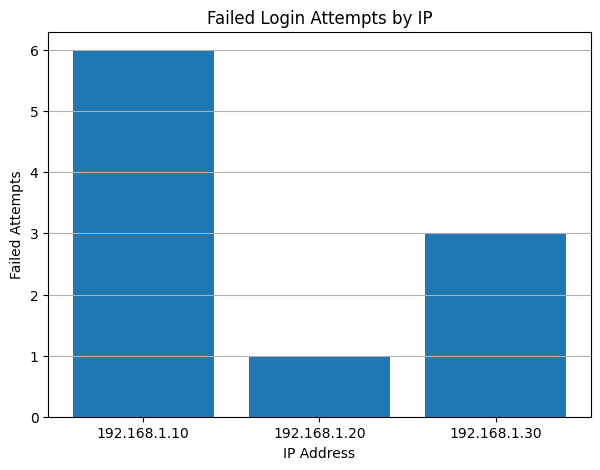


========== FINAL REPORT ==========
Total Log Entries      : 12
Failed Logins          : 10
Successful Logins      : 2
Brute Force Attacks    : 1

Analysis Completed Successfully.


In [1]:

import pandas as pd
import matplotlib.pyplot as plt
from datetime import datetime


logs = [
["2026-08-03 10:00:01","192.168.1.10","admin","FAILED"],
["2026-08-03 10:00:15","192.168.1.10","admin","FAILED"],
["2026-08-03 10:00:40","192.168.1.10","admin","FAILED"],
["2026-08-03 10:01:00","192.168.1.10","admin","FAILED"],
["2026-08-03 10:01:20","192.168.1.10","admin","FAILED"],
["2026-08-03 10:01:35","192.168.1.10","admin","FAILED"],
["2026-08-03 10:02:00","192.168.1.20","john","FAILED"],
["2026-08-03 10:02:20","192.168.1.20","john","SUCCESS"],
["2026-08-03 10:03:00","192.168.1.30","alice","FAILED"],
["2026-08-03 10:03:10","192.168.1.30","alice","FAILED"],
["2026-08-03 10:03:20","192.168.1.30","alice","FAILED"],
["2026-08-03 10:04:00","192.168.1.40","root","SUCCESS"]
]

df = pd.DataFrame(logs, columns=["Timestamp","IP Address","Username","Status"])

df.to_csv("sample_logs.csv", index=False)

print("Sample log file created successfully.\n")


log = pd.read_csv("sample_logs.csv")

print("Authentication Logs")
print(log)


failed = log[log["Status"]=="FAILED"]

failed_count = failed.groupby("IP Address").size().reset_index(name="Failed Attempts")

threshold = 5

failed_count["Brute Force"] = failed_count["Failed Attempts"].apply(
    lambda x: "YES" if x >= threshold else "NO"
)

print("\nFailed Login Summary")
print(failed_count)


print("\n==============================")
print("SECURITY ALERTS")
print("==============================")

attack_found = False

for index,row in failed_count.iterrows():

    if row["Brute Force"]=="YES":
        attack_found=True
        print(f" ALERT: Brute-force attack detected")
        print(f" IP Address : {row['IP Address']}")
        print(f" Failed Attempts : {row['Failed Attempts']}")
        print("--------------------------------")

if not attack_found:
    print("No brute-force attacks detected.")


failed_count.to_csv("BruteForce_Report.csv", index=False)

print("\nReport saved as BruteForce_Report.csv")


plt.figure(figsize=(7,5))
plt.bar(failed_count["IP Address"], failed_count["Failed Attempts"])

plt.title("Failed Login Attempts by IP")
plt.xlabel("IP Address")
plt.ylabel("Failed Attempts")

plt.grid(axis='y')

plt.show()


print("\n========== FINAL REPORT ==========")

total_failed = len(failed)

total_success = len(log[log["Status"]=="SUCCESS"])

total_attack = len(failed_count[failed_count["Brute Force"]=="YES"])

print("Total Log Entries      :", len(log))
print("Failed Logins          :", total_failed)
print("Successful Logins      :", total_success)
print("Brute Force Attacks    :", total_attack)

print("\nAnalysis Completed Successfully.")